In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
# Read data
df = pd.read_csv("Advertising.csv")

# Subset first 5 rows
dfs = df.iloc[:5,]
dfs

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Obtain input values
dfs_x = dfs.iloc[:, 1:4]
dfs_x

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [4]:
# Obtain output values
y = dfs.iloc[:,-1] #sales (output)
y

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [5]:
# X matrix
X = pd.DataFrame(dfs_x)
one = [1, 1, 1, 1, 1]
X["one"] = one
X

,TV,Radio,Newspaper,one
0,230.1,37.8,69.2,1
1,44.5,39.3,45.1,1
2,17.2,45.9,69.3,1
3,151.5,41.3,58.5,1
4,180.8,10.8,58.4,1


In [6]:
# Transpose of X
X_transpose = np.transpose(X)
X_transpose

,0,1,2,3,4
TV,230.1,44.5,17.2,151.5,180.8
Radio,37.8,39.3,45.9,41.3,10.8
Newspaper,69.2,45.1,69.3,58.5,58.4
one,1.0,1.0,1.0,1.0,1.0


In [7]:
# Transpose of X multipled by X
X_transpose_X = np.dot(X_transpose, X)
X_transpose_X

array([[1.1086299e+05, 1.9445700e+04, 3.8543300e+04, 6.2410000e+02],
       [1.9445700e+04, 6.9024700e+03, 1.0615830e+04, 1.7510000e+02],
       [3.8543300e+04, 1.0615830e+04, 1.8457950e+04, 3.0050000e+02],
       [6.2410000e+02, 1.7510000e+02, 3.0050000e+02, 5.0000000e+00]])

In [8]:
# Transpose of X multipled by y
X_transpose_y = np.dot(X_transpose, y)
X_transpose_y

array([10843.04,  2574.34,  4478.46,    73.2 ])

In [9]:
X_transpose_X_inv = np.linalg.inv(X_transpose_X)

In [10]:
beta = np.dot( X_transpose_X_inv, X_transpose_y )
beta

array([ 0.07054431,  0.23961665, -0.04017846, -0.14199017])

In [11]:
dfs['pred_TV'] = beta.item(3) +  beta.item(0)* dfs['TV']
dfs['pred_Radio'] = beta.item(3) +  beta.item(1)* dfs['Radio']
dfs['pred_News'] = beta.item(3) +  beta.item(2)* dfs['Newspaper']
dfs

,Unnamed: 0,TV,Radio,Newspaper,Sales,pred_TV,pred_Radio,pred_News
0,1,230.1,37.8,69.2,22.1,16.090256,8.915519,-2.922340
1,2,44.5,39.3,45.1,10.4,2.997232,9.274944,-1.954039
2,3,17.2,45.9,69.3,9.3,1.071372,10.856414,-2.926358
3,4,151.5,41.3,58.5,18.5,10.545473,9.754177,-2.492430
4,5,180.8,10.8,58.4,12.9,12.612421,2.445870,-2.488412


In [41]:
def obj(w):
    m1, m2, m3, b = w
    tv = dfs.loc[:5, 'TV'].values
    radio = dfs.loc[:5, 'Radio'].values
    news = dfs.loc[:5, 'Newspaper'].values
    y = dfs.loc[:,'Sales'].values
    pred_Sales = (m1 * tv) + (m2 * radio) + (m3 * news) + b

    return ((pred_Sales - y) ** 2).mean()

In [42]:
res = minimize(obj, x0 = [0, 0, 0, 0])
res.x

array([ 0.07054428,  0.23961653, -0.04017871, -0.1419681 ])

In [56]:
optimized_m1, optimized_m2, optimized_m3, optimized_b = res.x
tv_data = dfs['TV'].values
radio_data = dfs['Radio'].values
news_data = dfs['Newspaper'].values
actual_sales = dfs['Sales'].values
predicted_sales = (optimized_m1 * tv_data) + (optimized_m2 * radio_data) + (optimized_m3 * news_data) + optimized_b

predicted_sales

array([22.36741001, 10.60212241,  9.28540776, 18.09119926, 12.85386052])

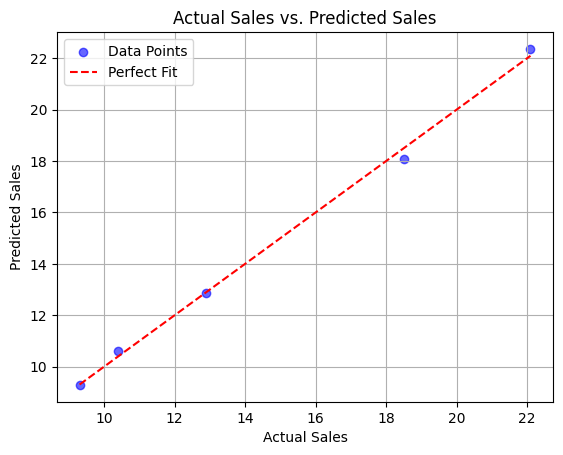

In [57]:
plt.scatter(actual_sales, predicted_sales, color='blue', alpha=0.6, label='Data Points')

perfect_line = np.linspace(min(actual_sales), max(actual_sales), 100)
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', label='Perfect Fit')

plt.title('Actual Sales vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True)
plt.show()

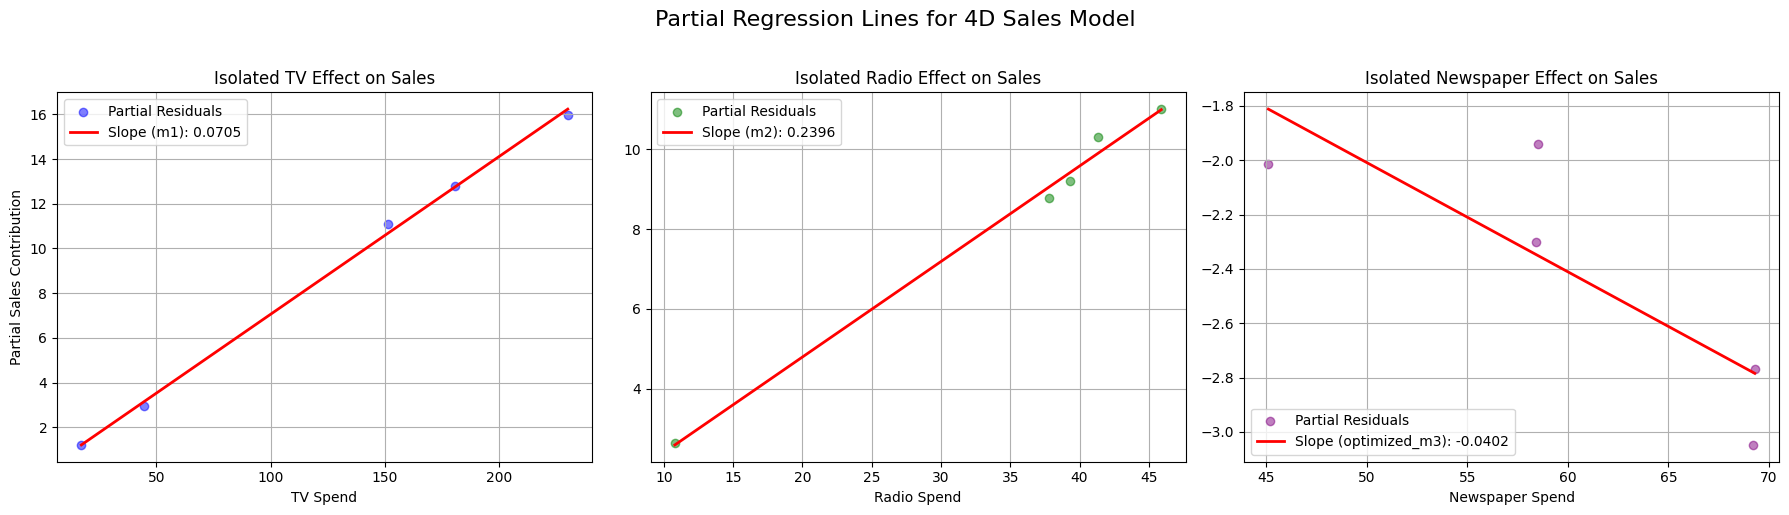

In [70]:
# --- PLOTTING PARTIAL RESIDUALS (How to visualize 4D in 2D) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: TV isolated effect
# Formula: Actual Sales minus the effects of Radio and Newspaper
tv_residual = y - (optimized_m2 * radio_data + optimized_m3 * news_data + optimized_b)
axes[0].scatter(tv_data, tv_residual, color='blue', alpha=0.5, label='Partial Residuals')
axes[0].plot(np.sort(tv_data), optimized_m1 * np.sort(tv_data), color='red', linewidth=2, label=f'Slope (m1): {optimized_m1:.4f}')
axes[0].set_title('Isolated TV Effect on Sales')
axes[0].set_xlabel('TV Spend')
axes[0].set_ylabel('Partial Sales Contribution')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Radio isolated effect
radio_residual = y - (optimized_m1 * tv_data + optimized_m3 * news_data + optimized_b)
axes[1].scatter(radio_data, radio_residual, color='green', alpha=0.5, label='Partial Residuals')
axes[1].plot(np.sort(radio_data), optimized_m2 * np.sort(radio_data), color='red', linewidth=2, label=f'Slope (m2): {optimized_m2:.4f}')
axes[1].set_title('Isolated Radio Effect on Sales')
axes[1].set_xlabel('Radio Spend')
axes[1].legend()
axes[1].grid(True)

# Plot 3: Newspaper isolated effect
news_residual = y - (optimized_m1 * tv_data + optimized_m2 * radio_data + optimized_b)
axes[2].scatter(news_data, news_residual, color='purple', alpha=0.5, label='Partial Residuals')
axes[2].plot(np.sort(news_data), optimized_m3 * np.sort(news_data), color='red', linewidth=2, label=f'Slope (optimized_m3): {optimized_m3:.4f}')
axes[2].set_title('Isolated Newspaper Effect on Sales')
axes[2].set_xlabel('Newspaper Spend')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Partial Regression Lines for 4D Sales Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()